In [ ]:
# Name: Temur Rustamov
# Student number: C00280204
#Project: Fashion MNIST GAN — Generative Adversarial Network for Fashion Image Synthesis

In [45]:
# Name: Temur Rustamov
# Student number: C00280204
#Project: Fashion MNIST GAN — Generative Adversarial Network for Fashion Image Synthesis

import sys
import tensorflow as tf

print(sys.executable)
print(tf.__version__)
print(tf.config.list_physical_devices())
print(tf.config.list_physical_devices('GPU'))
import tensorflow as tf
print(tf.config.list_physical_devices('GPU'))


/Users/timichtimovich/tf-metal-venv/bin/python3.12
2.18.1
[PhysicalDevice(name='/physical_device:CPU:0', device_type='CPU'), PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]
[PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]
[PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [46]:
#section 1: import dependencies
# !pip install tensorflow matplotlib tensorflow-datasets

import tensorflow as tf
import tensorflow_datasets as tfds
import numpy as np
from matplotlib import pyplot as plt
import os

# gpu configuration since TensorFlow allocates all available GPU memory at startup which causes problems
gpus = tf.config.experimental.list_physical_devices('GPU')
for gpu in gpus:
    tf.config.experimental.set_memory_growth(gpu, True)
print(f"GPUs available: {len(gpus)}")

GPUs available: 1


In [48]:
# section 2: data loading and preprocessing
ds = tfds.load('fashion_mnist', split='train')

# We only need the images for GAN training.
sample = ds.as_numpy_iterator().next()
print(f"Sample image shape: {sample['image'].shape}")  # (28, 28, 1)
print(f"Sample label: {sample['label']}")               # e.g. 2 (pullover)

Sample image shape: (28, 28, 1)
Sample label: 2


2026-03-27 04:00:48.216586: W tensorflow/core/kernels/data/cache_dataset_ops.cc:914] The calling iterator did not fully read the dataset being cached. In order to avoid unexpected truncation of the dataset, the partially cached contents of the dataset  will be discarded. This can happen if you have an input pipeline similar to `dataset.cache().take(k).repeat()`. You should use `dataset.take(k).cache().repeat()` instead.


2026-03-27 04:00:51.447201: W tensorflow/core/kernels/data/cache_dataset_ops.cc:914] The calling iterator did not fully read the dataset being cached. In order to avoid unexpected truncation of the dataset, the partially cached contents of the dataset  will be discarded. This can happen if you have an input pipeline similar to `dataset.cache().take(k).repeat()`. You should use `dataset.take(k).cache().repeat()` instead.


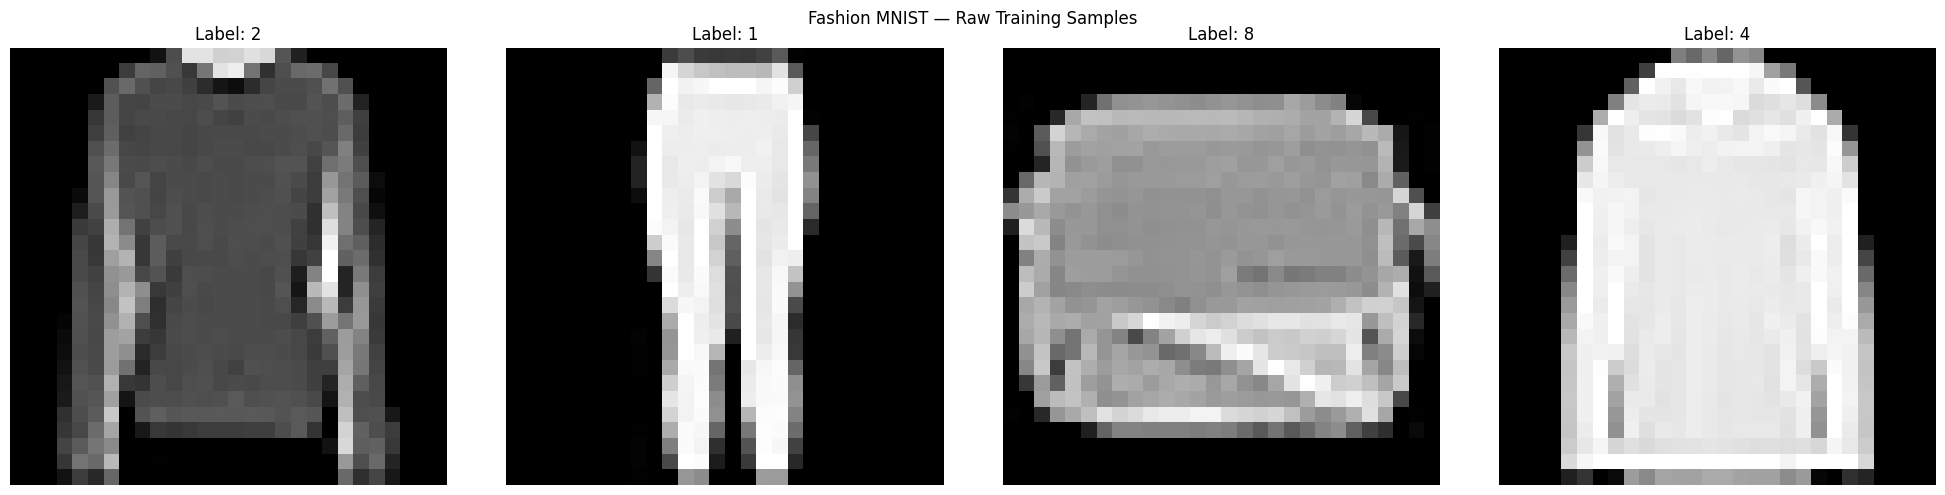

In [49]:
# section 3: visualizing raw data
# we want to inspect data before building a model
dataiterator = ds.as_numpy_iterator()
fig, ax = plt.subplots(ncols=4, figsize=(20, 5))
for idx in range(4):
    sample = dataiterator.next()
    # np.squeeze removes the single channel dimension (28,28,1) -> (28,28)
    # so matplotlib can display it as a 2D grayscale image.
    ax[idx].imshow(np.squeeze(sample['image']), cmap='gray')
    ax[idx].title.set_text(f"Label: {sample['label']}")
    ax[idx].axis('off')
plt.suptitle('Fashion MNIST — Raw Training Samples')
plt.tight_layout()
plt.show()

In [50]:
# section 4: preprocessing pipeline
# NN train much better when input values are in a small range like. Raw pixels are 0-255 and if we divide by 255 this will normalise from 0 to 1 which mathces the Generetor's sigmoid output range.

def scale_images(data):

    # Returns:
    #     tf.Tensor: The normalised image tensor of shape (28, 28, 1).

    image = tf.cast(data['image'], tf.float32)
    return image / 255.0

In [51]:
# Reload the dataset (iterators are consumed after use) and apply preprocessing.
ds = tfds.load('fashion_mnist', split='train')
ds = ds.map(scale_images)
# cache will store the preprocessed dataset in memory after the 1st epoch
ds = ds.cache()
ds = ds.shuffle(60000) # randomise the order of training examples
ds = ds.batch(128) # groups images into batches of 128
ds = ds.prefetch(64) #overlaps data loading with model training
print(f"Batched dataset shape: {ds.as_numpy_iterator().next().shape}")

Batched dataset shape: (128, 28, 28, 1)


In [52]:
# section 5: building neural networks
from tensorflow.keras.models import Sequential  # For stacking layers linearly
from tensorflow.keras.layers import (
    Conv2D,         # 2D Convolutional layer core of CNNs
    Dense,          # Fully connected layer core of ANNs
    Flatten,        # 2D feature maps to 1D vector
    Reshape,        # 1D vector to 2D feature maps
    LeakyReLU,
    Dropout,        # Regularisation technique
    UpSampling2D
)

# building the Generator Network
#  The Generator will take a random noise vector of size 128 and
#     transforms it into a grayscale image through a series of layers.
#     That is the reverse of a CNN classifier instead of going from
#     images to labels, we go from noise to images.
def build_generator():
    model = Sequential()

    # noise vector -> spatial feature map
    model.add(Dense(7 * 7 * 128, input_dim=128))
    model.add(LeakyReLU(0.2))
    model.add(Reshape((7, 7, 128)))
    # Upsampling block 1: 7x7 -> 14x14
    model.add(UpSampling2D())
    model.add(Conv2D(128, 5, padding='same'))
    model.add(LeakyReLU(0.2))
    # Upsampling block 2: 14x14 -> 28x28
    model.add(UpSampling2D())
    model.add(Conv2D(128, 5, padding='same'))
    model.add(LeakyReLU(0.2))
    # Refinement convolution block 1
    model.add(Conv2D(128, 4, padding='same'))
    model.add(LeakyReLU(0.2))
    # Refinement convolution block 2
    model.add(Conv2D(128, 4, padding='same'))
    model.add(LeakyReLU(0.2))
    # Output layer: reduce to 1 channel, sigmoid bounds output to [0, 1]
    model.add(Conv2D(1, 4, padding='same', activation='sigmoid'))

    return model

In [53]:
# section 6: building the Discriminator Network
# section 5: building neural networks
from tensorflow.keras.models import Sequential  # For stacking layers linearly
from tensorflow.keras.layers import (
    Conv2D,         # 2D Convolutional layer core of CNNs
    Dense,          # Fully connected layer core of ANNs
    Flatten,        # 2D feature maps to 1D vector
    Reshape,        # 1D vector to 2D feature maps
    LeakyReLU,
    Dropout,        # Regularisation technique
    UpSampling2D
)

def build_discriminator():
    # The Discriminator is a standard CNN binary classifier. It takes an image as input and outputs a single probability: 1 = real, 0 = fake.We are using convolutional
    # layers to extract hierarchical spatial features for classification.
    model = Sequential()

    # Conv Block 1: input 28x28x1 -> 24x24x32
    model.add(Conv2D(32, 5, input_shape=(28, 28, 1)))
    model.add(LeakyReLU(0.2))
    model.add(Dropout(0.4))

    # Conv Block 2: 24x24x32 -> 20x20x64
    model.add(Conv2D(64, 5))
    model.add(LeakyReLU(0.2))
    model.add(Dropout(0.4))

    # Conv Block 3: 20x20x64 -> 16x16x128
    model.add(Conv2D(128, 5))
    model.add(LeakyReLU(0.2))
    model.add(Dropout(0.4))

    # Conv Block 4: 16x16x128 -> 12x12x256
    model.add(Conv2D(256, 5))
    model.add(LeakyReLU(0.2))
    model.add(Dropout(0.4))

    # Flatten: 12x12x256 = 36864 -> 1D vector
    model.add(Flatten())
    model.add(Dropout(0.4))

    # Output: binary classification (real vs fake)
    model.add(Dense(1, activation='sigmoid'))

    return model

In [55]:
# section 7: constructing the training loop
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.losses import BinaryCrossentropy
# we need Adap optimiser since thats the standard optimiser for deep learning.It combines the benefits of momentum and adapts learning rate per parameter.
g_opt = Adam(learning_rate=0.0001)
d_opt = Adam(learning_rate=0.00001)
g_loss = BinaryCrossentropy()
d_loss = BinaryCrossentropy()


In [56]:
# section 8: building custom GAN model
from tensorflow.keras.models import Model
class FashionGAN(Model):


    def __init__(self, generator, discriminator, *args, **kwargs):
        super().__init__(*args, **kwargs)
        self.generator = generator
        self.discriminator = discriminator

    def compile(self, g_opt, d_opt, g_loss, d_loss, *args, **kwargs):
        super().compile(*args, **kwargs)
        self.g_opt = g_opt
        self.d_opt = d_opt
        self.g_loss = g_loss
        self.d_loss = d_loss

    def train_step(self, batch):
        # Execute one training step: train discriminator, then train generator.
        #
        # This is the CORE of GAN training. Each call processes one batch and:
        # 1. Generates fake images from random noise
        # 2. Trains the discriminator to distinguish real from fake
        # 3. Trains the generator to fool the discriminator
        real_images = batch
        batch_size = tf.shape(real_images)[0]

        # generates fake images from random noise
        fake_images = self.generator(
            tf.random.normal((batch_size, 128)), training=False
        )

        # Goal: teach the discriminator to output 1 for real images, 0 for fakes.
        with tf.GradientTape() as d_tape:
            yhat_real = self.discriminator(real_images, training=True)
            yhat_fake = self.discriminator(fake_images, training=True)
            yhat_realfake = tf.concat([yhat_real, yhat_fake], axis=0)

            # creating ground truth labels: real=1, fake=0
            y_realfake = tf.concat(
                [tf.ones_like(yhat_real), tf.zeros_like(yhat_fake)], axis=0
            )
            noise_real = -0.15 * tf.random.uniform(tf.shape(yhat_real))
            noise_fake = 0.15 * tf.random.uniform(tf.shape(yhat_fake))
            y_realfake += tf.concat([noise_real, noise_fake], axis=0)

            # computing discriminator loss using binary cross-entropy
            total_d_loss = self.d_loss(y_realfake, yhat_realfake)

        dgrad = d_tape.gradient(
            total_d_loss, self.discriminator.trainable_variables
        )
        self.d_opt.apply_gradients(
            zip(dgrad, self.discriminator.trainable_variables)
        )

        # Goal: make the generator produce images that the discriminator
        # classifies as output close to 1.
        with tf.GradientTape() as g_tape:

            gen_images = self.generator(
                tf.random.normal((batch_size, 128)), training=True
            )

            predicted_labels = self.discriminator(gen_images, training=False)


            # we compute the loss as if all fake images should be
            # classified as real (1). The loss will be high when the
            # discriminator correctly identifies fakes
            total_g_loss = self.g_loss(
                tf.ones_like(predicted_labels), predicted_labels
            )

        ggrad = g_tape.gradient(
            total_g_loss, self.generator.trainable_variables
        )
        self.g_opt.apply_gradients(
            zip(ggrad, self.generator.trainable_variables)
        )

        return {"d_loss": total_d_loss, "g_loss": total_g_loss}

In [57]:
# section 9: building traning callback for visual monitoring
from tensorflow.keras.preprocessing.image import array_to_img
from tensorflow.keras.callbacks import Callback

os.makedirs('images', exist_ok=True)

    # Keras Callback that generates and saves sample images at the end of each epoch.
    # GANs cannot be evaluated by loss alone since low loss does not necessarily mean
    # high-quality images .
class ModelMonitor(Callback):

    def __init__(self, num_img=3, latent_dim=128):
        self.num_img = num_img
        self.latent_dim = latent_dim

    def on_epoch_end(self, epoch, logs=None):

        # Generate random noise and flat vector to match
        random_latent_vectors = tf.random.normal(
            (self.num_img, self.latent_dim)
        )

        # Generate images from noise
        generated_images = self.model.generator(random_latent_vectors)
        generated_images = generated_images * 255.0
        generated_images = generated_images.numpy()

        # save each generated image
        for i in range(self.num_img):
            img = array_to_img(generated_images[i])
            img.save(os.path.join('images', f'generated_img_{epoch}_{i}.png'))



/Users/timichtimovich/tf-metal-venv/lib/python3.12/site-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
/Users/timichtimovich/tf-metal-venv/lib/python3.12/site-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


True
True
Epoch 1/20


2026-03-27 04:01:36.140984: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:117] Plugin optimizer for device_type GPU is enabled.


469/469 ━━━━━━━━━━━━━━━━━━━━ 304s 637ms/step - d_loss: 0.4749 - g_loss: 0.7206
Epoch 2/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 305s 651ms/step - d_loss: 0.6959 - g_loss: 0.7989
Epoch 3/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 304s 648ms/step - d_loss: 0.6955 - g_loss: 0.6927
Epoch 4/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 303s 646ms/step - d_loss: 0.7862 - g_loss: 0.4450
Epoch 5/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 299s 637ms/step - d_loss: 0.6539 - g_loss: 0.6556
Epoch 6/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 300s 639ms/step - d_loss: 0.7420 - g_loss: 0.5781
Epoch 7/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 303s 646ms/step - d_loss: 0.6849 - g_loss: 0.5429
Epoch 8/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 306s 653ms/step - d_loss: 0.6649 - g_loss: 0.6500
Epoch 9/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 295s 629ms/step - d_loss: 0.5194 - g_loss: 1.2088
Epoch 10/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 295s 629ms/step - d_loss: 0.3738 - g_loss: 0.1689
Epoch 11/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 294s 626ms/step - d_loss: 0.5058 - g_loss: 0.6403
Epoch 12/20
469/469

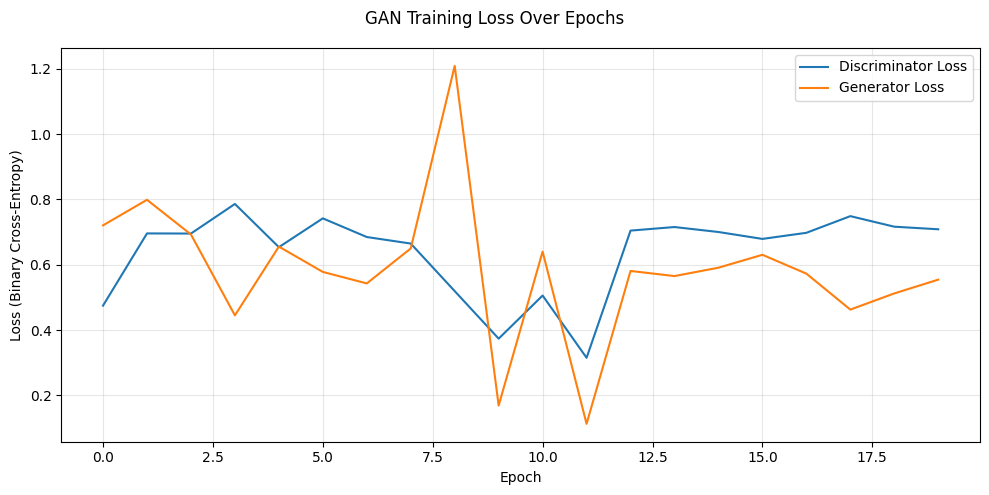

Loss plot saved to loss_plot.png


In [59]:
# section 10: training the GAN
generator = build_generator()
discriminator = build_discriminator()
print('generator' in globals())
print('discriminator' in globals())
fashgan = FashionGAN(generator, discriminator)
# Compile with our separate optimisers and loss functions
fashgan.compile(g_opt, d_opt, g_loss, d_loss)
hist = fashgan.fit(ds, epochs=20, callbacks=[ModelMonitor()]) # training here with 20 epochs

# analysing training health: healthy = d_loss around 0.5, unhealthy = g_loss will drop very low
plt.figure(figsize=(10, 5))
plt.suptitle('GAN Training Loss Over Epochs')
plt.plot(hist.history['d_loss'], label='Discriminator Loss')
plt.plot(hist.history['g_loss'], label='Generator Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss (Binary Cross-Entropy)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('loss_plot.png', dpi=150)
plt.show()
print("Loss plot saved to loss_plot.png")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 253ms/step


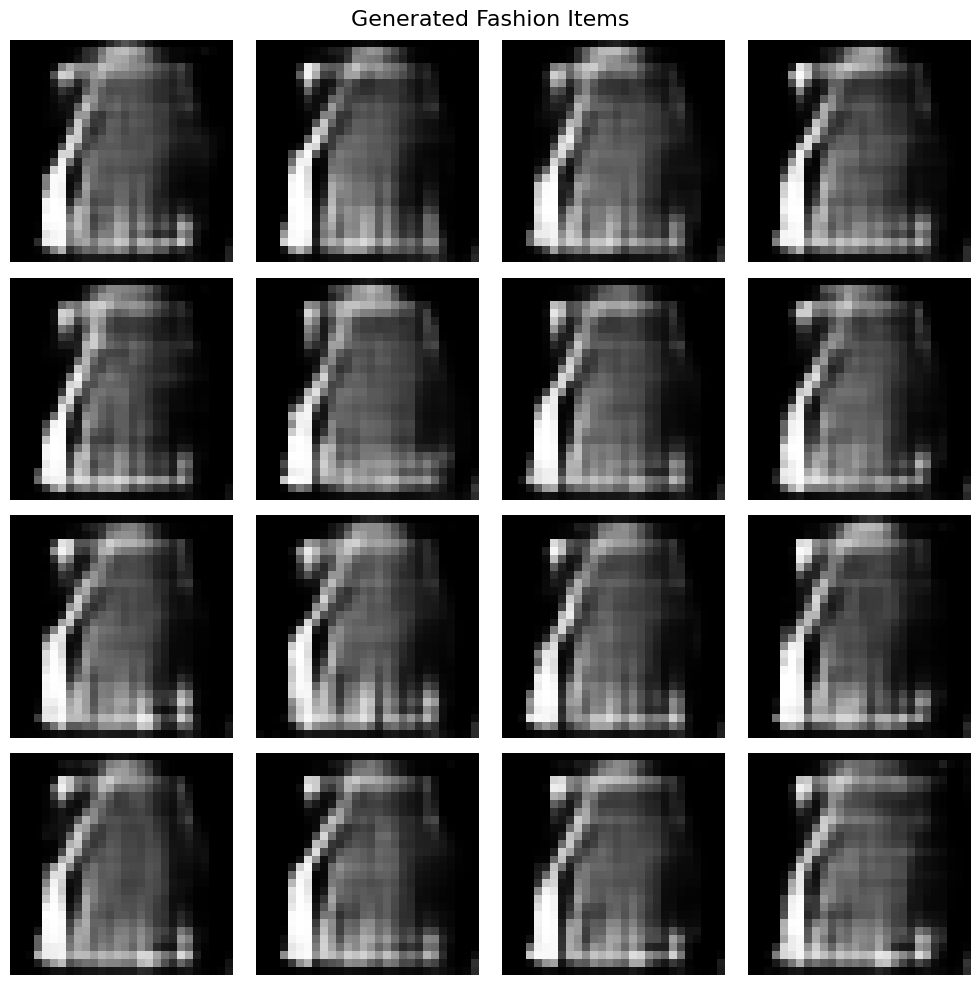

Generated image grid saved to generated_grid.png



Models saved: generator.h5, discriminator.h5


In [60]:
#section 11: testing the generator
imgs = generator.predict(tf.random.normal((16, 128)))

fig, ax = plt.subplots(ncols=4, nrows=4, figsize=(10, 10))
for r in range(4):
    for c in range(4):
        idx = r * 4 + c  # Correct 2D-to-1D index mapping
        ax[r][c].imshow(np.squeeze(imgs[idx]), cmap='gray')
        ax[r][c].axis('off')
plt.suptitle('Generated Fashion Items', fontsize=16)
plt.tight_layout()
plt.savefig('generated_grid.png', dpi=150)
plt.show()
print("Generated image grid saved to generated_grid.png")
generator.save('generator.h5')
discriminator.save('discriminator.h5')
print("\nModels saved: generator.h5, discriminator.h5")